In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import pandas as pd

df = pd.read_csv("W1D4_EDA/cleaned_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (8, 4)

Columns:
['State', 'Region', 'Population_Millions', 'Literacy_Rate']

First 5 rows:


,State,Region,Population_Millions,Literacy_Rate
0,Karnataka,South,61.1,75.4
1,Tamil Nadu,South,72.1,80.1
2,Kerala,South,33.4,94.0
3,Maharashtra,West,112.4,82.3
4,Gujarat,West,60.4,78.0


In [5]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())

Data Types:
State                      str
Region                     str
Population_Millions    float64
Literacy_Rate          float64
dtype: object

Missing Values:
State                  0
Region                 0
Population_Millions    0
Literacy_Rate          0
dtype: int64

Unique Values:
State                  8
Region                 4
Population_Millions    8
Literacy_Rate          8
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

# Create a copy so the original dataset remains unchanged
df_label = df.copy()

# Apply LabelEncoder to Region
label_encoder = LabelEncoder()
df_label["Region_Encoded"] = label_encoder.fit_transform(df_label["Region"])

print("Label Encoding Result:")
display(df_label[["Region", "Region_Encoded"]])

print("\nEncoding Mapping:")
for category, value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(category, "->", value)

Label Encoding Result:


,Region,Region_Encoded
0,South,2
1,South,2
2,South,2
3,West,3
4,West,3
5,North,1
6,North,1
7,East,0



Encoding Mapping:
East -> 0
North -> 1
South -> 2
West -> 3


In [7]:
from sklearn.preprocessing import OneHotEncoder

# Create a copy
df_onehot = df.copy()

# Create OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Encode Region
encoded = onehot_encoder.fit_transform(df_onehot[["Region"]])

# Create DataFrame for encoded columns
encoded_df = pd.DataFrame(
    encoded,
    columns=onehot_encoder.get_feature_names_out(["Region"])
)

# Combine with original data
df_onehot = pd.concat(
    [df_onehot.reset_index(drop=True), encoded_df],
    axis=1
)

print("One-Hot Encoding Result:")
display(df_onehot)

One-Hot Encoding Result:


,State,Region,Population_Millions,Literacy_Rate,Region_East,Region_North,Region_South,Region_West
0,Karnataka,South,61.1,75.4,0.0,0.0,1.0,0.0
1,Tamil Nadu,South,72.1,80.1,0.0,0.0,1.0,0.0
2,Kerala,South,33.4,94.0,0.0,0.0,1.0,0.0
3,Maharashtra,West,112.4,82.3,0.0,0.0,0.0,1.0
4,Gujarat,West,60.4,78.0,0.0,0.0,0.0,1.0
5,Rajasthan,North,68.5,66.1,0.0,1.0,0.0,0.0
6,Punjab,North,27.7,75.8,0.0,1.0,0.0,0.0
7,West Bengal,East,91.3,76.3,1.0,0.0,0.0,0.0


In [8]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy
df_ordinal = df.copy()

# Create OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Encode Region
df_ordinal["Region_Encoded"] = ordinal_encoder.fit_transform(
    df_ordinal[["Region"]]
)

print("Ordinal Encoding Result:")
display(df_ordinal[["Region", "Region_Encoded"]])

print("\nEncoding Categories:")
print(ordinal_encoder.categories_)

Ordinal Encoding Result:


,Region,Region_Encoded
0,South,2.0
1,South,2.0
2,South,2.0
3,West,3.0
4,West,3.0
5,North,1.0
6,North,1.0
7,East,0.0



Encoding Categories:
[array(['East', 'North', 'South', 'West'], dtype=object)]


In [9]:
print("Encoding Methods - Trade-offs\n")

print("1. LabelEncoder:")
print("- Simple and easy to use")
print("- Converts categories into numbers")
print("- Can create a false sense of order")
print("- Best suited for target labels")

print("\n2. OneHotEncoder:")
print("- Creates separate 0/1 columns")
print("- Does not create artificial ordering")
print("- Can increase the number of columns")
print("- Good for nominal categorical features")

print("\n3. OrdinalEncoder:")
print("- Converts categories into ordered numbers")
print("- Useful when categories have a real order")
print("- Should not be used for unordered categories")

Encoding Methods - Trade-offs

1. LabelEncoder:
- Simple and easy to use
- Converts categories into numbers
- Can create a false sense of order
- Best suited for target labels

2. OneHotEncoder:
- Creates separate 0/1 columns
- Does not create artificial ordering
- Can increase the number of columns
- Good for nominal categorical features

3. OrdinalEncoder:
- Converts categories into ordered numbers
- Useful when categories have a real order
- Should not be used for unordered categories


In [10]:
numeric_cols = ["Population_Millions", "Literacy_Rate"]

X_numeric = df[numeric_cols].copy()

print("Numerical Features:")
display(X_numeric)

Numerical Features:


,Population_Millions,Literacy_Rate
0,61.1,75.4
1,72.1,80.1
2,33.4,94.0
3,112.4,82.3
4,60.4,78.0
5,68.5,66.1
6,27.7,75.8
7,91.3,76.3


In [11]:
from sklearn.preprocessing import StandardScaler

# Create scaler
standard_scaler = StandardScaler()

# Fit and transform numerical features
X_standard = standard_scaler.fit_transform(X_numeric)

# Convert back to DataFrame
df_standard = pd.DataFrame(
    X_standard,
    columns=numeric_cols
)

print("Before StandardScaler:")
display(X_numeric)

print("\nAfter StandardScaler:")
display(df_standard)

Before StandardScaler:


,Population_Millions,Literacy_Rate
0,61.1,75.4
1,72.1,80.1
2,33.4,94.0
3,112.4,82.3
4,60.4,78.0
5,68.5,66.1
6,27.7,75.8
7,91.3,76.3



After StandardScaler:


,Population_Millions,Literacy_Rate
0,-0.182947,-0.421369
1,0.239608,0.217481
2,-1.247016,2.106846
3,1.787694,0.516517
4,-0.209837,-0.067963
5,0.101317,-1.685477
6,-1.465976,-0.366999
7,0.977157,-0.299036


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
minmax_scaler = MinMaxScaler()

# Fit and transform numerical features
X_minmax = minmax_scaler.fit_transform(X_numeric)

# Convert back to DataFrame
df_minmax = pd.DataFrame(
    X_minmax,
    columns=numeric_cols
)

print("Before MinMaxScaler:")
display(X_numeric)

print("\nAfter MinMaxScaler:")
display(df_minmax)

Before MinMaxScaler:


,Population_Millions,Literacy_Rate
0,61.1,75.4
1,72.1,80.1
2,33.4,94.0
3,112.4,82.3
4,60.4,78.0
5,68.5,66.1
6,27.7,75.8
7,91.3,76.3



After MinMaxScaler:


,Population_Millions,Literacy_Rate
0,0.394333,0.333333
1,0.524203,0.501792
2,0.067296,1.000000
3,1.000000,0.580645
4,0.386068,0.426523
5,0.481700,0.000000
6,0.000000,0.347670
7,0.750885,0.365591


In [13]:
from sklearn.preprocessing import RobustScaler

# Create scaler
robust_scaler = RobustScaler()

# Fit and transform numerical features
X_robust = robust_scaler.fit_transform(X_numeric)

# Convert back to DataFrame
df_robust = pd.DataFrame(
    X_robust,
    columns=numeric_cols
)

print("Before RobustScaler:")
display(X_numeric)

print("\nAfter RobustScaler:")
display(df_robust)

Before RobustScaler:


,Population_Millions,Literacy_Rate
0,61.1,75.4
1,72.1,80.1
2,33.4,94.0
3,112.4,82.3
4,60.4,78.0
5,68.5,66.1
6,27.7,75.8
7,91.3,76.3



After RobustScaler:


,Population_Millions,Literacy_Rate
0,-0.159140,-0.353535
1,0.313978,0.595960
2,-1.350538,3.404040
3,2.047312,1.040404
4,-0.189247,0.171717
5,0.159140,-2.232323
6,-1.595699,-0.272727
7,1.139785,-0.171717


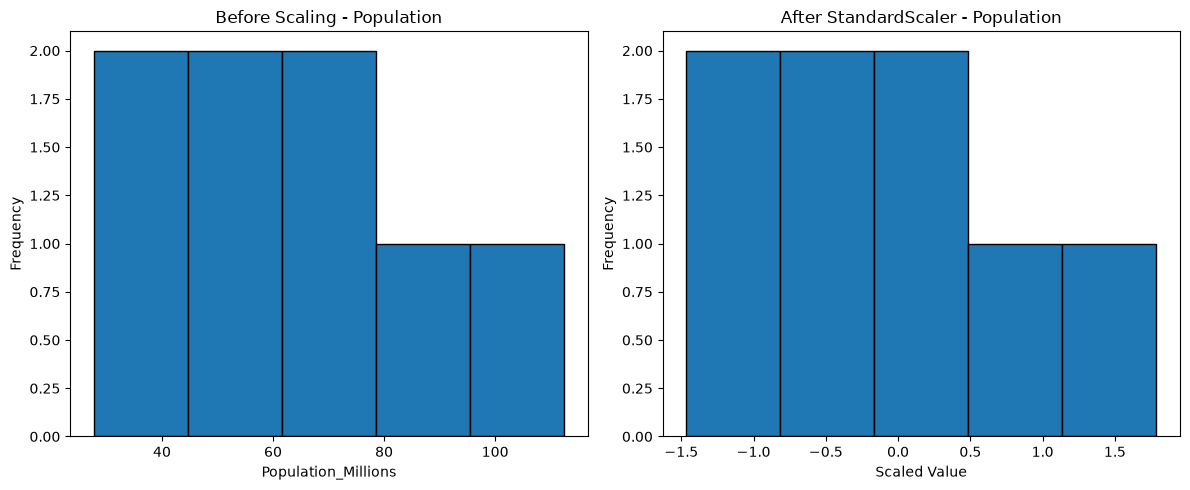

In [14]:
import matplotlib.pyplot as plt

# Plot Population_Millions before and after scaling
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_numeric["Population_Millions"], bins=5, edgecolor="black")
plt.title("Before Scaling - Population")
plt.xlabel("Population_Millions")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df_standard["Population_Millions"], bins=5, edgecolor="black")
plt.title("After StandardScaler - Population")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

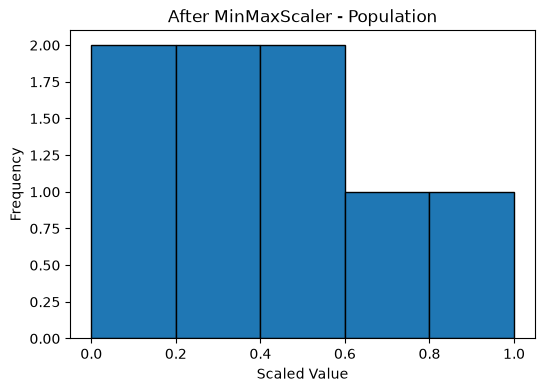

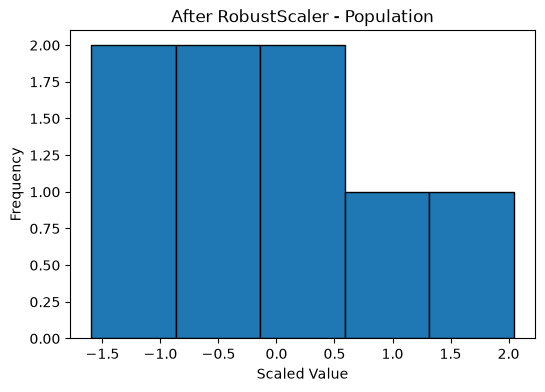

In [15]:
import matplotlib.pyplot as plt

# MinMaxScaler distribution
plt.figure(figsize=(6, 4))
plt.hist(df_minmax["Population_Millions"], bins=5, edgecolor="black")
plt.title("After MinMaxScaler - Population")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()


# RobustScaler distribution
plt.figure(figsize=(6, 4))
plt.hist(df_robust["Population_Millions"], bins=5, edgecolor="black")
plt.title("After RobustScaler - Population")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

In [16]:
# Create a copy
df_features = df.copy()

# Feature engineering
df_features["Population_per_Literacy"] = (
    df_features["Population_Millions"] / df_features["Literacy_Rate"]
)

df_features["Population_Literacy_Product"] = (
    df_features["Population_Millions"] * df_features["Literacy_Rate"]
)

print("Engineered Features:")
display(df_features)

Engineered Features:


,State,Region,Population_Millions,Literacy_Rate,Population_per_Literacy,Population_Literacy_Product
0,Karnataka,South,61.1,75.4,0.810345,4606.94
1,Tamil Nadu,South,72.1,80.1,0.900125,5775.21
2,Kerala,South,33.4,94.0,0.355319,3139.60
3,Maharashtra,West,112.4,82.3,1.365735,9250.52
4,Gujarat,West,60.4,78.0,0.774359,4711.20
5,Rajasthan,North,68.5,66.1,1.036309,4527.85
6,Punjab,North,27.7,75.8,0.365435,2099.66
7,West Bengal,East,91.3,76.3,1.196592,6966.19


In [17]:
# One-hot encode Region
region_encoded = pd.get_dummies(
    df_features["Region"],
    prefix="Region",
    dtype=int
)

# Combine numerical and encoded features
X = pd.concat(
    [
        df_features[
            [
                "Population_Millions",
                "Population_per_Literacy",
                "Population_Literacy_Product"
            ]
        ],
        region_encoded
    ],
    axis=1
)

# Target
y = df_features["Literacy_Rate"]

print("Features available for selection:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Features available for selection:
['Population_Millions', 'Population_per_Literacy', 'Population_Literacy_Product', 'Region_East', 'Region_North', 'Region_South', 'Region_West']

Number of features: 7


In [18]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 5 features
selector = SelectKBest(score_func=f_regression, k=5)

X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Top 5 Selected Features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

print("\nFeature Scores:")
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

display(feature_scores)

Top 5 Selected Features:
1. Population_Millions
2. Population_per_Literacy
3. Region_North
4. Region_South
5. Region_West

Feature Scores:


,Feature,Score
4,Region_North,3.245771
5,Region_South,1.909478
1,Population_per_Literacy,0.917917
0,Population_Millions,0.214237
6,Region_West,0.102316
3,Region_East,0.077640
2,Population_Literacy_Product,0.000207


In [19]:
print("Why the Top 5 Features Matter:\n")

feature_reasons = {
    "Population_Millions":
        "Represents the population size of the state and may help explain differences in literacy.",

    "Population_per_Literacy":
        "Combines population and literacy rate into a derived feature, capturing their relationship.",

    "Population_Literacy_Product":
        "Combines population and literacy rate and may capture their combined effect.",

    "Region_East":
        "Indicates whether the state belongs to the East region, allowing regional differences to be captured.",

    "Region_North":
        "Indicates whether the state belongs to the North region, allowing regional differences to be captured.",

    "Region_South":
        "Indicates whether the state belongs to the South region, allowing regional differences to be captured.",

    "Region_West":
        "Indicates whether the state belongs to the West region, allowing regional differences to be captured."
}

for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")
    print("   Why:", feature_reasons[feature])
    print()

Why the Top 5 Features Matter:

1. Population_Millions
   Why: Represents the population size of the state and may help explain differences in literacy.

2. Population_per_Literacy
   Why: Combines population and literacy rate into a derived feature, capturing their relationship.

3. Region_North
   Why: Indicates whether the state belongs to the North region, allowing regional differences to be captured.

4. Region_South
   Why: Indicates whether the state belongs to the South region, allowing regional differences to be captured.

5. Region_West
   Why: Indicates whether the state belongs to the West region, allowing regional differences to be captured.



In [20]:
scaling_comparison = pd.DataFrame({
    "Feature": numeric_cols,
    "Original Mean": X_numeric.mean().values,
    "StandardScaler Mean": df_standard.mean().values,
    "MinMaxScaler Mean": df_minmax.mean().values,
    "RobustScaler Mean": df_robust.mean().values
})

print("Scaling Comparison:")
display(scaling_comparison)

Scaling Comparison:


,Feature,Original Mean,StandardScaler Mean,MinMaxScaler Mean,RobustScaler Mean
0,Population_Millions,65.8625,1.110223e-16,0.450561,0.045699
1,Literacy_Rate,78.5000,-2.775558e-16,0.444444,0.272727


In [21]:
print("W2D1 Feature Engineering & Encoding Summary")
print("=" * 50)

print("\nEncoding:")
print("✓ LabelEncoder applied")
print("✓ OneHotEncoder applied")
print("✓ OrdinalEncoder applied")

print("\nScaling:")
print("✓ StandardScaler applied")
print("✓ MinMaxScaler applied")
print("✓ RobustScaler applied")

print("\nFeature Selection:")
print("✓ SelectKBest applied")
print("✓ Top 5 features selected")

print("\nW2D1 practical tasks completed successfully!")

W2D1 Feature Engineering & Encoding Summary

Encoding:
✓ LabelEncoder applied
✓ OneHotEncoder applied
✓ OrdinalEncoder applied

Scaling:
✓ StandardScaler applied
✓ MinMaxScaler applied
✓ RobustScaler applied

Feature Selection:
✓ SelectKBest applied
✓ Top 5 features selected

W2D1 practical tasks completed successfully!


# Viva Questions

### 1. When should you use OneHotEncoder vs OrdinalEncoder?

- Use OneHotEncoder for categorical data with no natural order, such as Region.
- Use OrdinalEncoder when categories have a meaningful order, such as Low, Medium, High.
- OneHotEncoder avoids creating an artificial numerical relationship between categories.

### 2. Why does StandardScaler not work well with outliers?

- StandardScaler uses the mean and standard deviation.
- Outliers can strongly affect the mean and standard deviation.
- Therefore, extreme values can affect the scaled results.
- RobustScaler is better when significant outliers are present.

### 3. What is feature leakage and how do you prevent it?

- Feature leakage happens when information that would not be available at prediction time is used to train a model.
- It can produce unrealistically high model performance.
- Prevent it by separating training and testing data before preprocessing and fitting transformations only on the training data.

# Encoding Trade-offs

| Method | Advantages | Disadvantages |
|---|---|---|
| LabelEncoder | Simple and easy | Can create artificial ordering |
| OneHotEncoder | No artificial ordering | Can create many columns |
| OrdinalEncoder | Useful for ordered categories | Not suitable for nominal categories |

For this dataset, OneHotEncoder is appropriate for Region because regions do not have a natural numerical order.

# Scaling Trade-offs

| Scaler | Advantages | Disadvantages |
|---|---|---|
| StandardScaler | Centers data around mean 0 | Sensitive to outliers |
| MinMaxScaler | Scales values to 0–1 | Sensitive to outliers |
| RobustScaler | More resistant to outliers | May produce less intuitive values |

RobustScaler is useful when a dataset contains significant outliers.